In [89]:
import torch
import torch.nn as nn
import os
import numpy as np
import torch.nn.functional as F
from tqdm import tqdm
from torchvision.utils import save_image, make_grid


In [90]:
dataset_path = './datasets/mnistfashion'

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 32

latent_dim = 20

lr = 1e-3
num_epochs = 50

In [91]:
from torchvision.datasets import FashionMNIST as MNIST
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

mnist_transform = transforms.Compose([
    transforms.ToTensor(), # [0, 255] -> [0, 1]
])

kwargs = {'num_workers': 1, 'pin_memory': True} if torch.cuda.is_available() else {}

train_dataset = MNIST(dataset_path, train=True, transform=mnist_transform, download=True)
test_dataset = MNIST(dataset_path, train=False, transform=mnist_transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, **kwargs)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, **kwargs)

canais_img = train_dataset[0][0].shape[0]
input_channels = canais_img
print(f'Número de canais da imagem: {canais_img}')

# Acessando o primeiro item do dataset
amostra_x, rotulo = train_dataset[0]

# Extraindo dimensões
canais = amostra_x.shape[0]
altura = amostra_x.shape[1]
largura = amostra_x.shape[2]
num_classes = 10

print(f"--- Info da Amostra ---")
print(f"Dimensões da Imagem: {canais} canais x {altura}px x {largura}px")
print(f"Rótulo (Label): {rotulo}") 

Número de canais da imagem: 1
--- Info da Amostra ---
Dimensões da Imagem: 1 canais x 28px x 28px
Rótulo (Label): 9


In [92]:
print(train_dataset.classes)
print(train_dataset.class_to_idx)

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
{'T-shirt/top': 0, 'Trouser': 1, 'Pullover': 2, 'Dress': 3, 'Coat': 4, 'Sandal': 5, 'Shirt': 6, 'Sneaker': 7, 'Bag': 8, 'Ankle boot': 9}


In [93]:
class Encoder(nn.Module):
    def __init__(self, input_channels, latent_dim, num_classes): # Adicionado num_classes
        super(Encoder, self).__init__()
        
        # O input_channels agora é original (1) + num_classes (10) = 11
        self.conv_layers = nn.Sequential(
            nn.Conv2d(input_channels + num_classes, 32, kernel_size=3, stride=2, padding=1), 
            # Input = [Imagem Real] + [Folha 0] + [Folha 1] + [Folha 0] ... [Folha 0]
            nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # 64 canais, 7x7 --> flat_features = 64*7*7
            nn.LeakyReLU(0.2),
            nn.Flatten() 
        )
        
        flat_features = 64 * 7 * 7 
        self.fc_mean = nn.Linear(flat_features, latent_dim) #(64*7*7*20)+20 = 62740
        self.fc_logvar = nn.Linear(flat_features, latent_dim) #(64*7*7*20)+20 = 62740

    def forward(self, x, y):
        # x: [batch, 1, 28, 28]
        # y: [batch, 10] (one-hot)
        
        # Expandimos o rótulo y para as dimensões da imagem [batch, 10, 28, 28]
        y_embedded = y.view(-1, 10, 1, 1).expand(-1, -1, x.size(2), x.size(3))
        
        # Concatenamos nos canais: entrada vira [batch, 11, 28, 28]
        x_cond = torch.cat([x, y_embedded], dim=1)
        
        h_ = self.conv_layers(x_cond)
        mean = self.fc_mean(h_)
        logvar = self.fc_logvar(h_)
        return mean, logvar

In [94]:
class Decoder(nn.Module):
    def __init__(self, latent_dim, output_channels, num_classes):
        super(Decoder, self).__init__()
        
        # A entrada agora é o vetor latente + o vetor da classe
        self.fc_upsample = nn.Linear(latent_dim + num_classes, 64 * 7 * 7)
        
        self.deconv_layers = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1), #(64, 7, 7) -> (32, 14, 14)
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(32, output_channels, kernel_size=3, stride=2, padding=1, output_padding=1), #(32, 14, 14) -> (1, 28, 28)
            nn.Sigmoid() # Para uso de distribuição Bernoulli, entre [0, 1]
        )

    def forward(self, z, y):
        # z: [batch, latent_dim], y: [batch, 10]
        z_cond = torch.cat([z, y], dim=1) # Concatena vetores [batch, [latent_dim] + [num_classes]]
        
        x = self.fc_upsample(z_cond)
        x = x.view(-1, 64, 7, 7) # Reshape para volume convolucional
        x = self.deconv_layers(x)
        return x

In [95]:
class Model(nn.Module):
    def __init__(self, Encoder, Decoder):
        super(Model, self).__init__()
        self.Encoder = Encoder
        self.Decoder = Decoder
    
    def reparameterize(self, mean, logvar):
        dp = torch.exp(0.5 * logvar)
        epsilon = torch.randn_like(dp).to(DEVICE)
        z = mean + dp * epsilon
        return z
    
    def forward(self, x, y):
        mean, logvar = self.Encoder(x, y)
        z = self.reparameterize(mean, logvar)
        x_hat = self.Decoder(z, y)
        return x_hat, mean, logvar
    

In [96]:
encoder = Encoder(input_channels, latent_dim, 10)
decoder = Decoder(latent_dim, input_channels, 10)
# import torchsummary as summary
model = Model(encoder, decoder).to(DEVICE)

# summary.summary(model, input_size=[(input_channels, 28, 28), (10, 1, 1)])


from torchinfo import summary

# 2. Definição dos tamanhos com o batch_size incluído
# Imagem: (Batch, Canais, Altura, Largura) -> (32, 1, 28, 28)
# Rótulo: (Batch, Classes) -> (32, 10)
input_shapes = [(batch_size, 1, 28, 28), (batch_size, 10)]

# 3. CHAMADA DO SUMMARY
# O dtypes garante que o modelo entenda que o label é um float (necessário para concatenação)
summary(model, input_size=input_shapes, dtypes=[torch.float, torch.float])

Layer (type:depth-idx)                   Output Shape              Param #
Model                                    [32, 1, 28, 28]           --
├─Encoder: 1-1                           [32, 20]                  --
│    └─Sequential: 2-1                   [32, 3136]                --
│    │    └─Conv2d: 3-1                  [32, 32, 14, 14]          3,200
│    │    └─LeakyReLU: 3-2               [32, 32, 14, 14]          --
│    │    └─Conv2d: 3-3                  [32, 64, 7, 7]            18,496
│    │    └─LeakyReLU: 3-4               [32, 64, 7, 7]            --
│    │    └─Flatten: 3-5                 [32, 3136]                --
│    └─Linear: 2-2                       [32, 20]                  62,740
│    └─Linear: 2-3                       [32, 20]                  62,740
├─Decoder: 1-2                           [32, 1, 28, 28]           --
│    └─Linear: 2-4                       [32, 3136]                97,216
│    └─Sequential: 2-5                   [32, 1, 28, 28]          

In [97]:
from torch.optim import Adam

# BCE_loss = nn.BCELoss()
# nn.functional.binary_cross_entropy(x_hat, x, reduction='sum')

def loss_(x, x_hat, mean, logvar):
    reproduction_loss = -torch.sum(x * torch.log(x_hat + 1e-10) + (1 - x) * torch.log(1 - x_hat + 1e-10))
    DKL = -0.5 * torch.sum(1 + logvar - mean.pow(2) - logvar.exp())
    return reproduction_loss + DKL

optimizer = Adam(model.parameters(), lr=lr)

In [98]:

# 1. Defina o caminho do arquivo
MODEL_PATH = "cvae_model.pth"

# 2. Tenta carregar o modelo se o arquivo existir
if os.path.exists(MODEL_PATH):
    print(f"✅ Arquivo '{MODEL_PATH}' encontrado! Carregando pesos...")
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model.eval() # Pronto para usar!
    train_needed = False
else:
    print("❌ Modelo não encontrado. O treino será iniciado.")
    train_needed = True

# 3. Só executa o treino se necessário
if train_needed:
    print("Starting training CVAE...")
    model.train()

    for epoch in range(num_epochs):
        overall_loss = 0
        for batch_idx, (x, rotulo) in enumerate(tqdm(train_loader)):
            x = x.view(-1, input_channels, altura, largura).to(DEVICE) # Garantindo que x tenha o formato correto para o Encoder
            y_cond = F.one_hot(rotulo, num_classes=10).float().to(DEVICE)
            optimizer.zero_grad()

            x_hat, mean, logvar = model(x, y_cond)

            if batch_idx == 0:
                print(f"--- Debug Batch 0 ---")
                # Exibe o número original (ex: 5)
                print(f"Rótulo Real (Classe): {rotulo[0].item()}")
                
                # Exibe o vetor One-Hot que foi para o modelo
                print(f"Vetor One-Hot (Condição): {y_cond[0].detach().cpu().numpy()}")
                
                # Exibe os parâmetros latentes
                print(f"Média (primeiros 5 valores): {mean[0][:5].detach().cpu().numpy()}")
                print(f"LogVar (primeiros 5 valores): {logvar[0][:5].detach().cpu().numpy()}")
                print(f"----------------------")

            loss = loss_(x, x_hat, mean, logvar)

            overall_loss += loss.item()
            loss.backward()

            # --- NOVO: Print do Primeiro Propagation ---
            if epoch == 0 and batch_idx == 0:
                print("\n=== DEBUG: PRIMEIRO PROPAGATION (GRADIENTES) ===")
                
                # 1. Gradiente no Encoder (Última camada linear antes do espaço latente)
                # Queremos ver se o erro conseguiu atravessar o 'reparameterize'
                enc_grad = model.Encoder.fc_mean.weight.grad
                print(f"Gradiente Médio na fc_mean do Encoder: {enc_grad.abs().mean().item():.8f}")

                # 2. Gradiente no Decoder (Primeira camada linear que recebe z)
                dec_grad = model.Decoder.fc_upsample.weight.grad
                print(f"Gradiente Médio na fc_upsample do Decoder: {dec_grad.abs().mean().item():.8f}")

                # 3. Gradiente nas Convoluções (Onde a imagem começa a ser desenhada)
                conv_grad = model.Decoder.deconv_layers[0].weight.grad
                print(f"Gradiente Médio na primeira Deconv: {conv_grad.abs().mean().item():.8f}")
                print("================================================\n")
            # --------------------------------------------

        
            optimizer.step()
        print("\tOverall Loss:", overall_loss, "\t(batch_idx+1): ", batch_idx+1, "\tBatch Size: ", batch_size)    
        print("\tEpoch", epoch + 1, "complete!", "\tAverage Loss: ", overall_loss / ((batch_idx+1)*batch_size))

    # 4. SALVAR APÓS O TREINO
    torch.save(model.state_dict(), MODEL_PATH)
    print(f"Finish!! Modelo treinado e salvo em: {MODEL_PATH}")

else:
    print("Pulei o treino porque o modelo já foi carregado.")

❌ Modelo não encontrado. O treino será iniciado.
Starting training CVAE...


  0%|          | 0/1875 [00:00<?, ?it/s]

--- Debug Batch 0 ---
Rótulo Real (Classe): 2
Vetor One-Hot (Condição): [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
Média (primeiros 5 valores): [-0.04323952  0.05447029 -0.01907726  0.01810954 -0.02641415]
LogVar (primeiros 5 valores): [ 0.00855402  0.00230772 -0.0185967  -0.01832135  0.03901083]
----------------------


  0%|          | 1/1875 [00:00<09:28,  3.29it/s]


=== DEBUG: PRIMEIRO PROPAGATION (GRADIENTES) ===
Gradiente Médio na fc_mean do Encoder: 0.28259301
Gradiente Médio na fc_upsample do Decoder: 0.31731278
Gradiente Médio na primeira Deconv: 2.94413996



...

	Overall Loss: 14103309.1484375 	(batch_idx+1):  1875 	Batch Size:  32
	Epoch 49 complete! 	Average Loss:  235.05515247395834


  0%|          | 3/1875 [00:00<01:08, 27.35it/s]

--- Debug Batch 0 ---
Rótulo Real (Classe): 4
Vetor One-Hot (Condição): [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
Média (primeiros 5 valores): [-0.16608383 -0.02088809  0.08110599  0.41238916  0.20363863]
LogVar (primeiros 5 valores): [-0.26689088 -3.1785164  -0.1002091  -0.4185362  -4.1480865 ]
----------------------


100%|██████████| 1875/1875 [00:54<00:00, 34.68it/s]

	Overall Loss: 14100989.471191406 	(batch_idx+1):  1875 	Batch Size:  32
	Epoch 50 complete! 	Average Loss:  235.01649118652344
Finish!! Modelo treinado e salvo em: cvae_model.pth


In [99]:

import matplotlib.pyplot as plt

In [100]:
model.eval()

with torch.no_grad():
    # 1. Capturamos o rótulo do test_loader
    for batch_idx, (x, rotulo) in enumerate(tqdm(test_loader)):
        
        # 2. Preparamos a imagem e o rótulo (One-Hot)
        x = x.view(-1, input_channels, altura, largura).to(DEVICE)
        y_cond = torch.nn.functional.one_hot(rotulo, num_classes=10).float().to(DEVICE)
        
        # 3. Passamos ambos para o modelo
        # No teste, geralmente só nos interessa o x_hat (reconstrução)
        x_hat, mean, logvar = model(x, y_cond)
        
        # O break está aqui para pegarmos apenas um batch para visualização posterior
        break

  0%|          | 0/313 [00:00<?, ?it/s]


In [101]:
# 1. Primeiro, defina a lista de nomes (garanta que esteja na ordem 0-9)
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

def show_image(x, idx, labels=None):
    print(f"Shape original recebido: {x.shape}")
    
    x = x.detach().cpu()
    x = x.permute(0, 2, 3, 1)
    
    grid_size = int(np.sqrt(idx))
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))
    
    if idx == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i in range(idx):
        if i < len(x):
            img_to_show = x[i].numpy()
            
            if img_to_show.shape[-1] == 1:
                img_to_show = img_to_show.squeeze(-1)
                axes[i].imshow(img_to_show, cmap='gray')
            else:
                axes[i].imshow(img_to_show)
            
            if labels is not None:
                if len(labels.shape) > 1:
                    label_val = torch.argmax(labels[i]).item()
                else:
                    label_val = labels[i].item()
                
                # ALTERAÇÃO AQUI: 
                # Usamos label_val para buscar o nome na lista class_names
                nome_classe = class_names[label_val]
                axes[i].set_title(f"{nome_classe} ({label_val})")
                
            axes[i].axis('off')
        else:
            axes[i].axis('off')

    plt.tight_layout()
    plt.show()

Shape original recebido: torch.Size([32, 1, 28, 28])


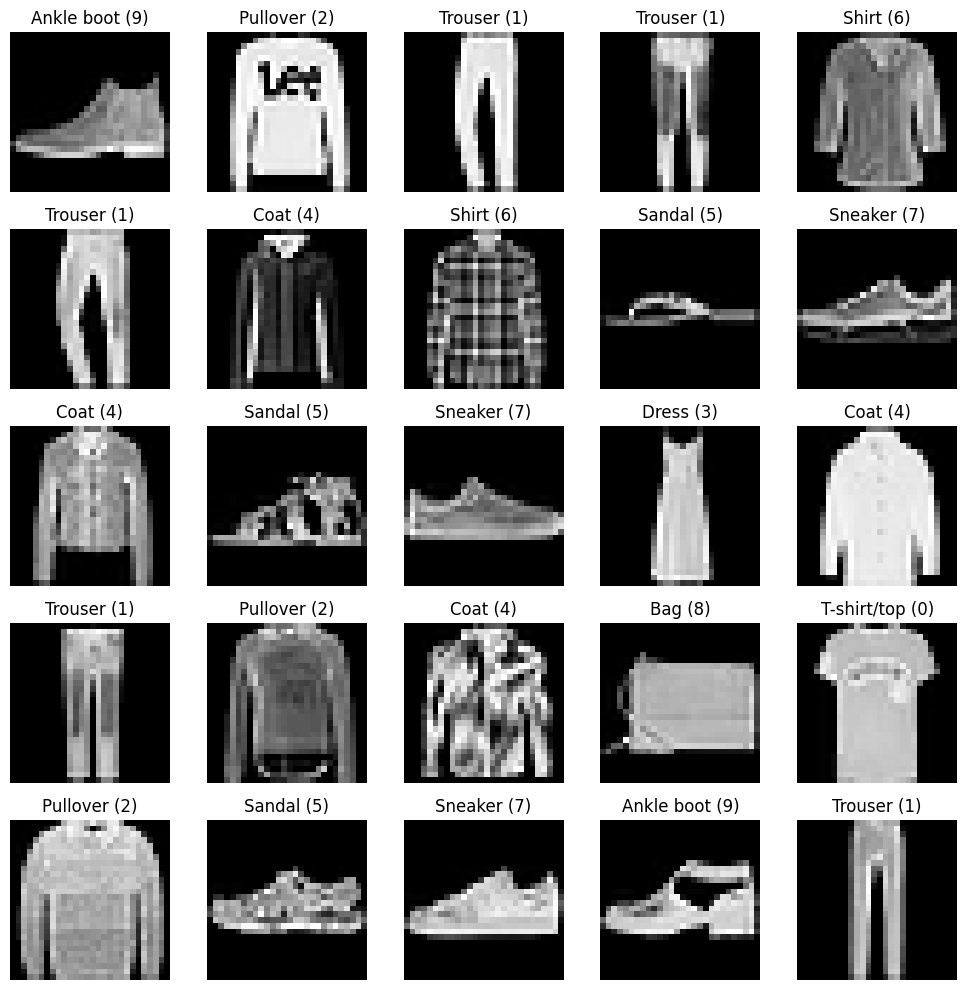

In [102]:
show_image(x, idx=25, labels=rotulo)

Shape original recebido: torch.Size([32, 1, 28, 28])


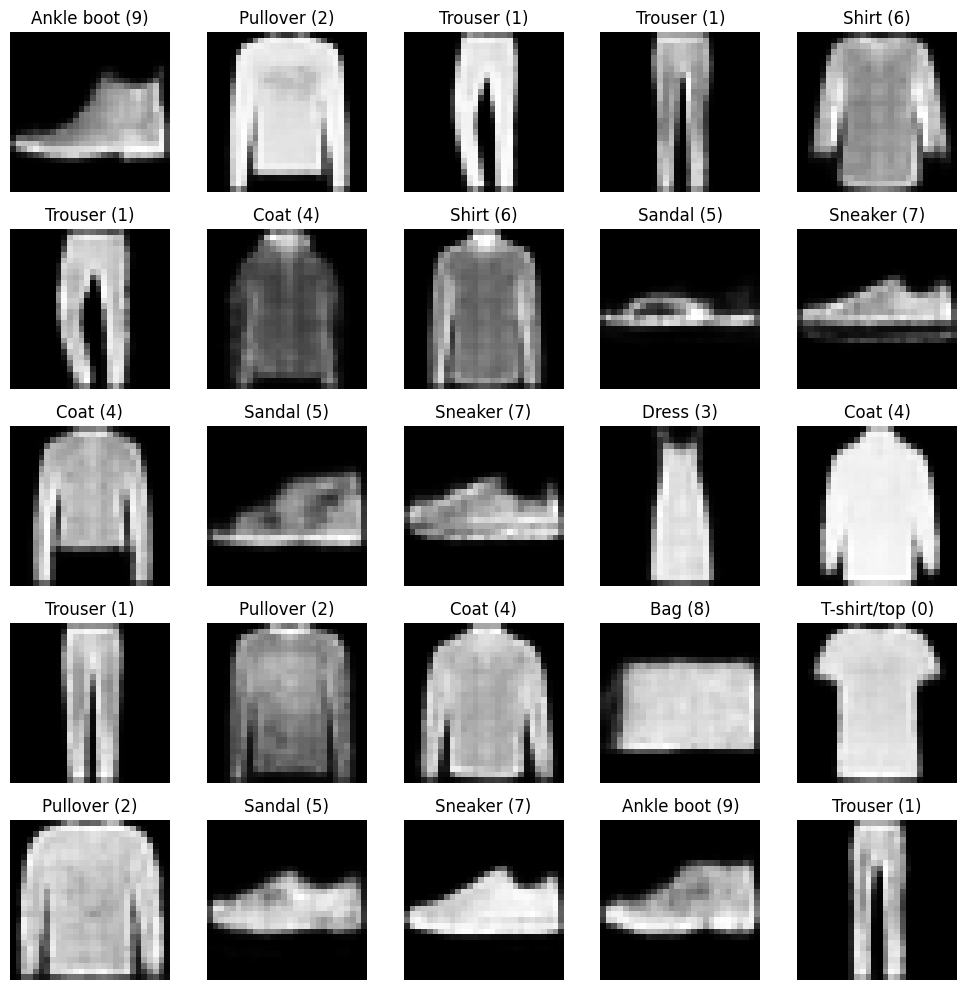

In [103]:
show_image(x_hat, idx=25, labels=rotulo)

  0%|          | 0/313 [00:00<?, ?it/s]


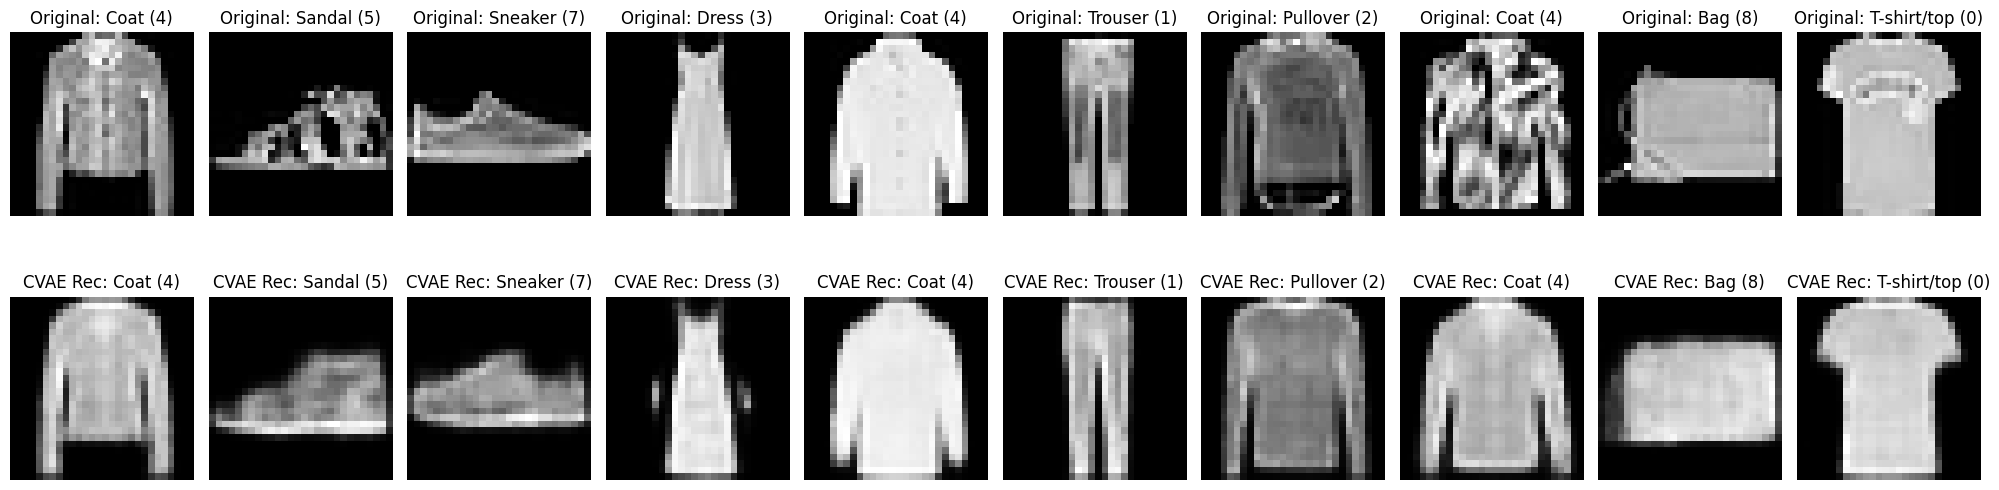

In [104]:
model.eval()
with torch.no_grad():
    # 1. Capturamos o rótulo do test_loader
    for batch_idx, (x, rotulo) in enumerate(tqdm(test_loader)):
        
        # 2. Preparamos a imagem e o rótulo (One-Hot)
        x = x.view(-1, input_channels, altura, largura).to(DEVICE)
        y_cond = torch.nn.functional.one_hot(rotulo, num_classes=10).float().to(DEVICE)
        
        # 3. Passamos ambos para o modelo
        # No teste, geralmente só nos interessa o x_hat (reconstrução)
        x_hat, mean, logvar = model(x, y_cond)
        
        # O break está aqui para pegarmos apenas um batch para visualização posterior
        break

n = 10 
plt.figure(figsize=(20, 6)) 

for i in range(n):
    # Pegamos o valor real do rótulo para colocar no título
    # Usamos i+10 para manter a lógica do seu índice original
    label_real = rotulo[i+10].item()

    # --- Imagem Original ---
    ax = plt.subplot(2, n, i + 1)
    img_original = x[i+10].cpu().permute(1, 2, 0)
    
    plt.imshow(img_original, cmap='gray')
    nome_classe = class_names[label_real]
    plt.title(f"Original: {nome_classe} ({label_real})") # Mostra o que a imagem REALMENTE é
    ax.axis('off')

    # --- Imagem Reconstruída ---
    ax = plt.subplot(2, n, i + 1 + n)
    img_reconstruida = x_hat[i+10].cpu().permute(1, 2, 0)
    
    plt.imshow(img_reconstruida, cmap='gray')
    # Mudamos o título de VAE para CVAE para ser condizente com o novo modelo
    plt.title(f"CVAE Rec: {nome_classe} ({label_real})") 
    ax.axis('off')

plt.tight_layout()
plt.show()

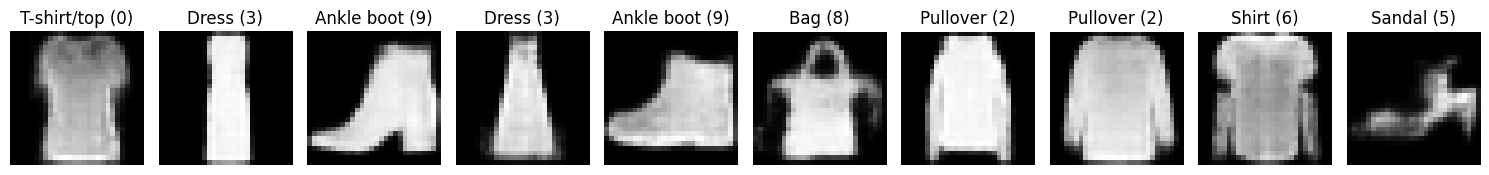

In [105]:
model.eval() # Garante que o modelo está em modo de inferência

n_geracoes = 10

with torch.no_grad():
    # 1. Criar 10 vetores latentes aleatórios (Distribuição Normal)
    z = torch.randn(n_geracoes, latent_dim).to(DEVICE)
    
    # 2. Criar 10 rótulos aleatórios entre 0 e 9
    rotulos_random = torch.randint(0, 10, (n_geracoes,)).to(DEVICE)
    
    # 3. Converter esses rótulos para One-Hot (formato que o Decoder espera)
    y_cond = torch.nn.functional.one_hot(rotulos_random, num_classes=10).float().to(DEVICE)
    
    # 4. Passar para o Decoder (repare que não usamos o Encoder aqui, pois estamos GERANDO)
    # No CVAE, o decoder recebe o ruído E a condição
    novas_imagens = model.Decoder(z, y_cond)

# --- Visualização ---
plt.figure(figsize=(15, 4))
for i in range(n_geracoes):
    ax = plt.subplot(1, n_geracoes, i + 1)
    
    # Prepara para o matplotlib (Canais por último)
    img = novas_imagens[i].cpu().permute(1, 2, 0).numpy()
    
    if img.shape[-1] == 1:
        img = img.squeeze(-1)
        
    plt.imshow(img, cmap='gray')
    nome_classe = class_names[rotulos_random[i].item()]
    plt.title(f"{nome_classe} ({rotulos_random[i].item()})")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [106]:
from sklearn.manifold import TSNE

model.eval()
latents = []
labels_list = []

with torch.no_grad():
    for x, y in test_loader: # Use o loader de teste
        x = x.to(DEVICE)
        # No CVAE, o encoder precisa do x e do y (one-hot)
        y_oh = torch.nn.functional.one_hot(y, num_classes=10).float().to(DEVICE)
        
        mu, _ = model.Encoder(x, y_oh)
        latents.append(mu.cpu())
        labels_list.append(y)

latents = torch.cat(latents, dim=0).numpy()
labels_list = torch.cat(labels_list, dim=0).numpy()

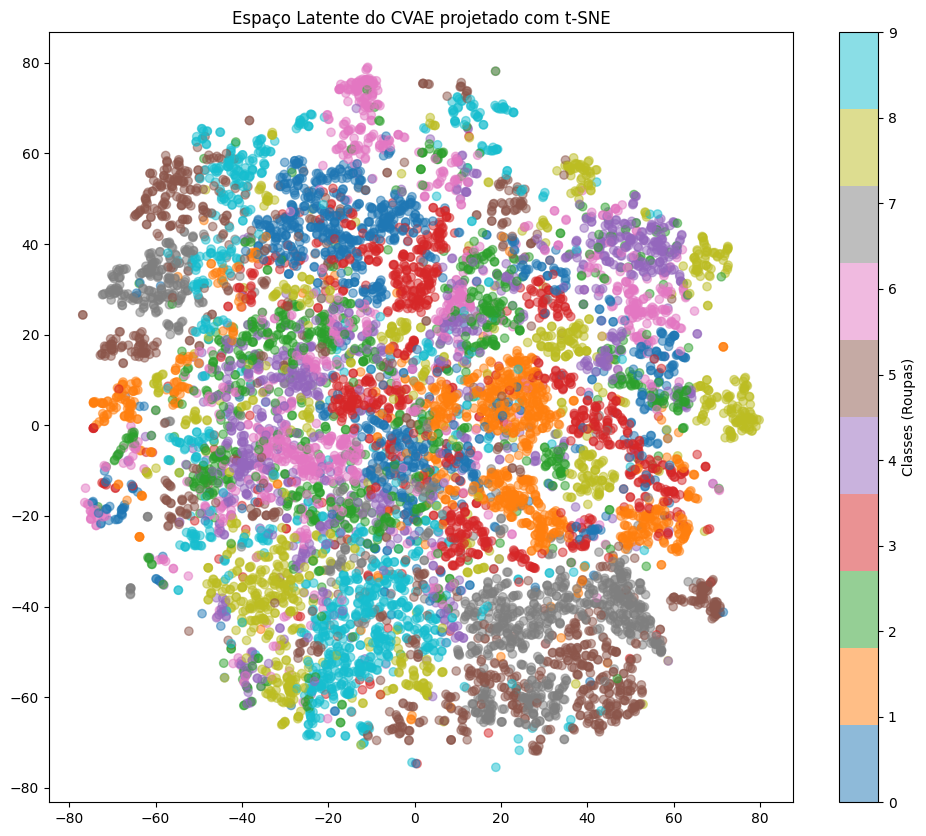

In [107]:
# Reduzindo de 15D para 2D
tsne = TSNE(n_components=2, random_state=42)
latents_2d = tsne.fit_transform(latents)

# Plotando
plt.figure(figsize=(12, 10))
scatter = plt.scatter(latents_2d[:, 0], latents_2d[:, 1], c=labels_list, cmap='tab10', alpha=0.5)
plt.colorbar(scatter, ticks=range(10), label='Classes (Roupas)')
plt.title("Espaço Latente do CVAE projetado com t-SNE")
plt.show()

Coletando 5000 amostras para o UMAP...
Rodando UMAP...


c:\Users\chena\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


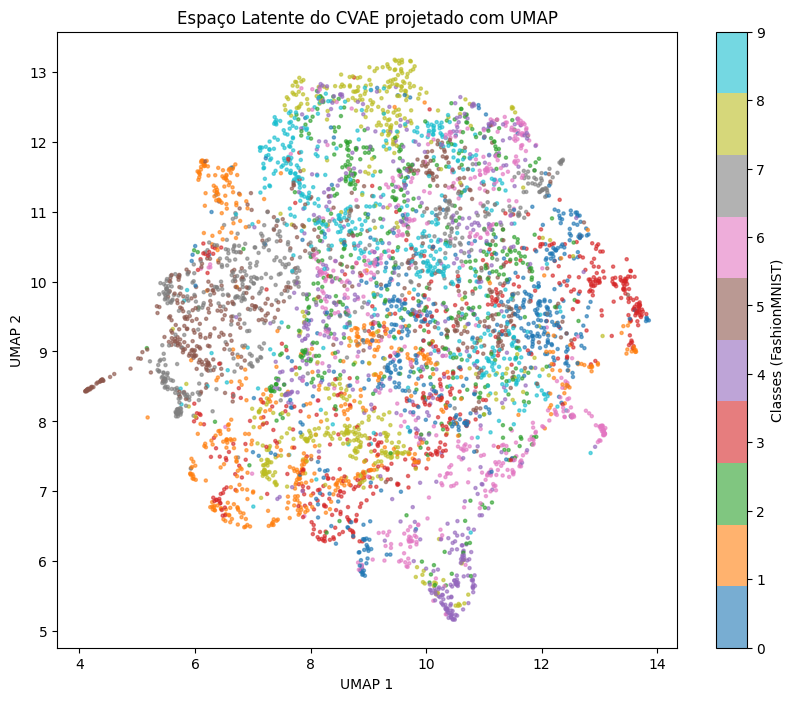

In [108]:
import umap

def plot_umap_latent_space(model, dataloader, device, num_samples=5000):
    model.eval()
    latents = []
    labels = []

    print(f"Coletando {num_samples} amostras para o UMAP...")
    
    with torch.no_grad():
        for x, rotulo in dataloader:
            x = x.to(device)
            # No CVAE, passamos a imagem e o rótulo para o encoder
            y_cond = torch.nn.functional.one_hot(rotulo, num_classes=10).float().to(device)
            
            # Pegamos apenas a MÉDIA (mean) como representação do ponto no espaço
            mu, _ = model.Encoder(x, y_cond) 
            
            latents.append(mu.cpu().numpy())
            labels.append(rotulo.numpy())
            
            # Para não demorar muito, paramos ao atingir num_samples
            if len(np.concatenate(latents)) >= num_samples:
                break

    # Transforma em arrays numpy
    latents = np.concatenate(latents)[:num_samples]
    labels = np.concatenate(labels)[:num_samples]

    # --- Configuração do UMAP ---
    # n_neighbors: Baixo foca em detalhes locais, Alto foca na visão global
    # min_dist: Controla o quão próximos os pontos podem ficar (0.1 é padrão)
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='euclidean', random_state=42)
    
    print("Rodando UMAP...")
    embedding = reducer.fit_transform(latents)

    # Plotagem
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(embedding[:, 0], embedding[:, 1], c=labels, cmap='tab10', s=5, alpha=0.6)
    plt.colorbar(scatter, label='Classes (FashionMNIST)')
    plt.title('Espaço Latente do CVAE projetado com UMAP')
    plt.xlabel('UMAP 1')
    plt.ylabel('UMAP 2')
    plt.show()

# Chamada da função:
plot_umap_latent_space(model, train_loader, DEVICE)

Gerando travessia para a classe 6...


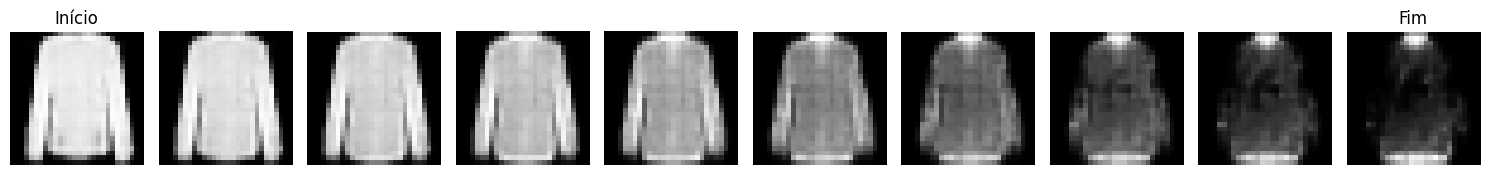

In [113]:
import torch
import matplotlib.pyplot as plt

def latent_traversal_corrigido(model, device, class_idx=0, num_steps=10):
    model.eval()
    
    # 1. Definimos dois pontos no espaço latente (z)
    # Usamos randn para pegar pontos dentro da distribuição normal que o modelo aprendeu
    z_start = torch.randn(1, 20).to(device) * -1.5
    z_end = torch.randn(1, 20).to(device) * 1.5
    
    # 2. Preparamos o rótulo fixo (y)
    # Criamos o One-Hot e garantimos que ele esteja no mesmo DEVICE (GPU/CPU) que o modelo
    y = torch.tensor([class_idx]).to(device)
    y_cond = torch.nn.functional.one_hot(y, num_classes=10).float().to(device)

    # 3. Criamos os passos da caminhada (Interpolação Linear)
    steps = torch.linspace(0, 1, num_steps)
    
    plt.figure(figsize=(15, 3))
    print(f"Gerando travessia para a classe {class_idx}...")

    with torch.no_grad():
        for i, t in enumerate(steps):
            # Interpolação linear entre os dois vetores z: z_t = (1-t)*z_start + t*z_end
            z_interp = z_start * (1 - t) + z_end * t
            
            # --- CHAMADA CORRIGIDA ---
            # Passando z e y_cond como argumentos separados para o decoder
            # Nota: usei .decoder (minúsculo) ou .Decoder conforme o nome no seu modelo
            generated_img = model.Decoder(z_interp, y_cond)
            
            # Plotagem
            plt.subplot(1, num_steps, i + 1)
            # Squeeze remove dimensões 1 (ex: [1, 1, 28, 28] -> [28, 28])
            plt.imshow(generated_img.cpu().squeeze(), cmap='gray')
            plt.axis('off')
            if i == 0: plt.title("Início")
            if i == num_steps - 1: plt.title("Fim")

    plt.tight_layout()
    plt.show()

# Chamada do teste
latent_traversal_corrigido(model, DEVICE, class_idx=6)

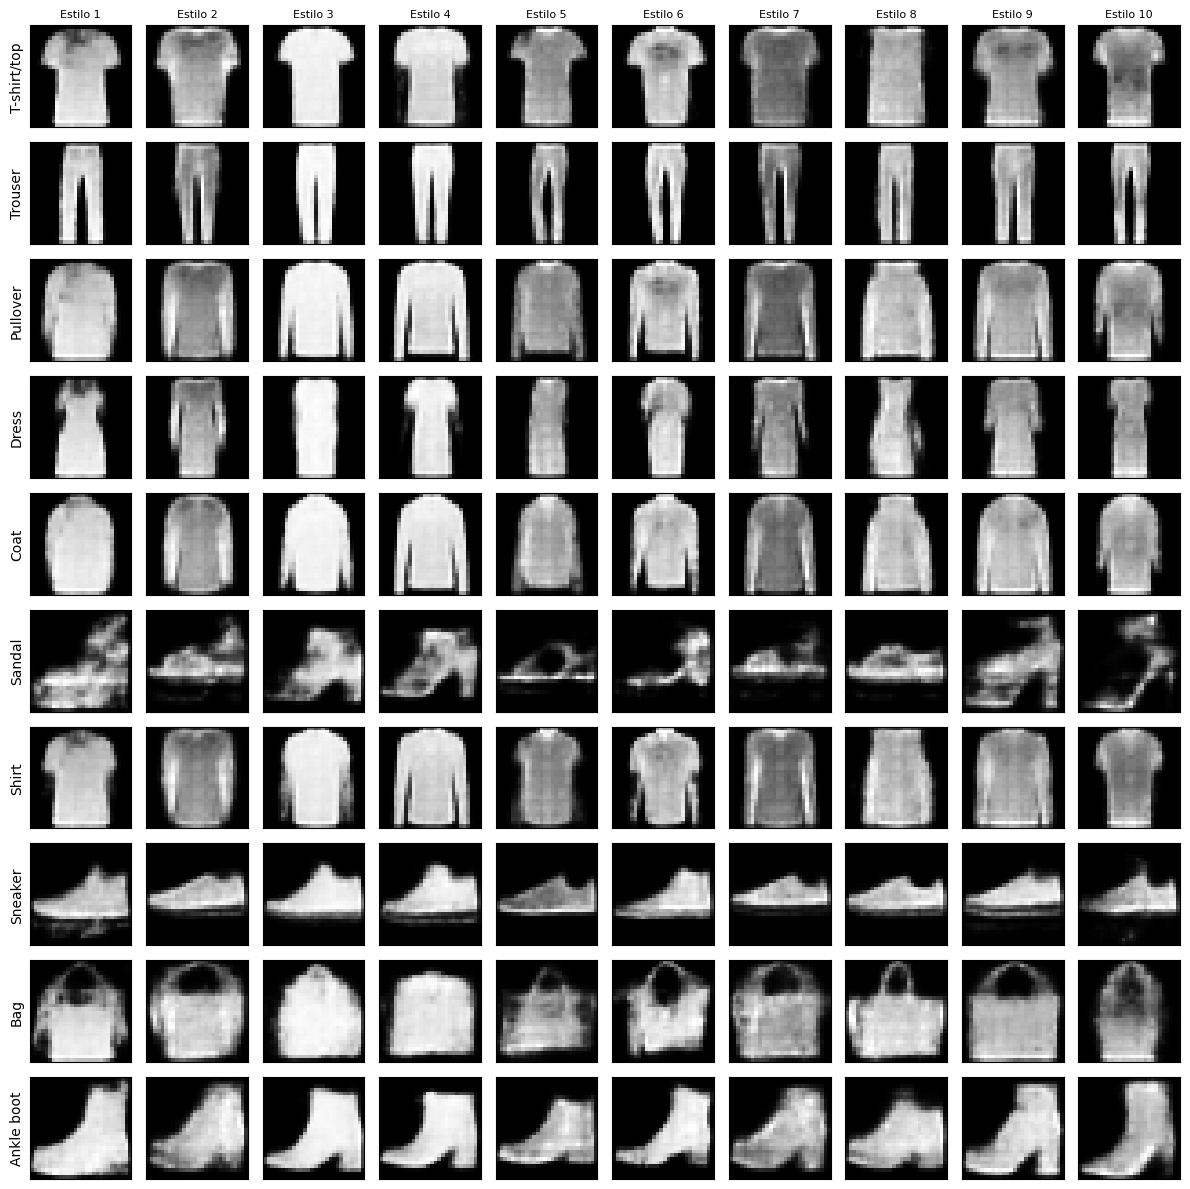

In [114]:
model.eval()

num_classes = 10
n_estilos = 10  # Quantas variações por classe

with torch.no_grad():
    # 1. Criamos 10 estilos fixos (z) para as colunas
    # Assim, a primeira coluna terá o mesmo 'estilo' para todas as roupas
    z = torch.randn(n_estilos, latent_dim).to(DEVICE)
    
    # 2. Criamos a grade de plotagem
    plt.figure(figsize=(12, 12))
    
    for i in range(num_classes):
        # Para cada linha, o rótulo (y) é fixo
        y_val = torch.full((n_estilos,), i, dtype=torch.long).to(DEVICE)
        y_cond = torch.nn.functional.one_hot(y_val, num_classes=10).float().to(DEVICE)
        
        # Geramos 10 imagens para essa classe usando os 10 estilos z
        imagens_geradas = model.Decoder(z, y_cond)
        
        for j in range(n_estilos):
            ax = plt.subplot(num_classes, n_estilos, i * n_estilos + j + 1)
            
            img = imagens_geradas[j].cpu().squeeze().numpy()
            plt.imshow(img, cmap='gray')
            
            # Labels apenas nas bordas para não poluir
            if j == 0:
                plt.ylabel(class_names[i], fontsize=10)
            if i == 0:
                plt.title(f"Estilo {j+1}", fontsize=8)
                
            ax.set_xticks([])
            ax.set_yticks([])

plt.tight_layout()
plt.show()